# Urban Heat Island (UHI) Analysis Workflow
## MSF Geo-Humanitarian Project — Tondo, Manila
**University of Salzburg · Z_GIS · Geo-Humanitarian Research Group**

---

### How to use this notebook
> **You only need to edit ONE cell** — `CONFIGURATION` — to change the study area.  
> Everything else runs automatically: data acquisition, LST computation, UHI mapping, vulnerability indexing, and statistics.

---


## 0. Google Earth Engine — Setup Guide

Before running this notebook you need a **GEE account** and a **GEE Cloud Project**:

### Step 1 — Create a GEE account
1. Go to [https://code.earthengine.google.com/register](https://code.earthengine.google.com/register)
2. Sign in with your Google account and accept the terms

### Step 2 — Create a Google Cloud Project
1. Go to [https://console.cloud.google.com/](https://console.cloud.google.com/)
2. Click **Select a Project** → **New Project** → name it (e.g. `uhi-msf-analysis`)
3. Go to [APIs & Services → Library](https://console.cloud.google.com/apis/library/earthengine.googleapis.com), select your project, click **Enable**
4. Copy your **Project ID** — paste it in Cell 0B below

---


In [1]:
# ============================================================
# 0A. INSTALL DEPENDENCIES
# ============================================================
!pip install earthengine-api folium pandas matplotlib seaborn geopandas -q
print("All packages installed.")


All packages installed.


In [2]:
# ============================================================
# 0B. AUTHENTICATE & INITIALIZE GOOGLE EARTH ENGINE
# ============================================================
# *** PASTE YOUR GEE CLOUD PROJECT ID BELOW ***
GEE_PROJECT = "uhi-msf-analysis"  # <-- Replace with your project ID

import ee
ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)

print(f"Earth Engine initialized with project: {GEE_PROJECT}")
print(f"Test: {ee.Date('2025-01-01').format('YYYY-MM-dd').getInfo()}")


Earth Engine initialized with project: uhi-msf-analysis
Test: 2025-01-01


In [3]:
# ============================================================
# 0C. IMPORTS
# ============================================================
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Helper: add an Earth Engine image layer to a folium map
def add_ee_layer(m, ee_image, vis_params, name, shown=True):
    """Add a GEE image as a tile layer on a folium map."""
    map_id = ee_image.getMapId(vis_params)
    folium.TileLayer(
        tiles=map_id['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True,
        show=shown
    ).add_to(m)

def make_map(center_lat, center_lon, zoom=14):
    """Create a folium map centered on the AOI."""
    return folium.Map(location=[center_lat, center_lon], zoom_start=zoom,
                      tiles='OpenStreetMap')

print("All libraries loaded.")


All libraries loaded.


---
## 1. CONFIGURATION — *Edit this cell only*
Change the Area of Interest (AOI), date ranges, and parameters below.  
Everything downstream adapts automatically.

---


In [4]:
# ============================================================
# 1. CONFIGURATION — *** CHANGE ONLY THIS CELL ***
# ============================================================

# ---------- AREA OF INTEREST ----------
# Option A: Bounding box [west, south, east, north]
AOI_BBOX = [120.950, 14.600, 120.985, 14.640]  # Tondo, Manila

# Option B: GEE asset (uncomment and comment out AOI_BBOX)
# AOI_ASSET = "FAO/GAUL/2015/level2"
# AOI_FILTER = ee.Filter.eq('ADM2_NAME', 'Manila')

# ---------- STUDY PERIOD ----------
YEAR_START = 2019
YEAR_END   = 2025

# ---------- SEASONS (months) ----------
DRY_MONTHS = [12, 1, 2, 3, 4, 5]
WET_MONTHS = [6, 7, 8, 9, 10, 11]

# ---------- CLOUD COVER THRESHOLD (%) ----------
MAX_CLOUD_COVER = 30

# ---------- UHI REFERENCE BUFFER (meters) ----------
UHI_BUFFER_M = 5000

# ---------- VULNERABILITY INDEX WEIGHTS (sum = 1.0) ----------
W_LST    = 0.30
W_POP    = 0.25
W_BUILD  = 0.20
W_NDVI   = 0.15
W_HEALTH = 0.10

# ---------- OUTPUT ----------
PROJECT_NAME = "UHI_Tondo_Manila"

assert abs(W_LST + W_POP + W_BUILD + W_NDVI + W_HEALTH - 1.0) < 0.001, "Weights must sum to 1.0"
print(f"Config loaded: {PROJECT_NAME} | AOI: {AOI_BBOX} | {YEAR_START}-{YEAR_END}")


Config loaded: UHI_Tondo_Manila | AOI: [120.95, 14.6, 120.985, 14.64] | 2019-2025


## 2. Define Area of Interest

In [5]:
# ============================================================
# 2. BUILD AOI GEOMETRY
# ============================================================
try:
    aoi = ee.FeatureCollection(AOI_ASSET).filter(AOI_FILTER).geometry()
    print("AOI loaded from asset.")
except NameError:
    aoi = ee.Geometry.Rectangle(AOI_BBOX)
    print("AOI created from bounding box.")

aoi_buffer = aoi.buffer(UHI_BUFFER_M)
aoi_ring   = aoi_buffer.difference(aoi)

center_lat = (AOI_BBOX[1] + AOI_BBOX[3]) / 2
center_lon = (AOI_BBOX[0] + AOI_BBOX[2]) / 2

# Preview map
m = make_map(center_lat, center_lon, zoom=13)
folium.GeoJson(aoi.getInfo(), name='AOI',
               style_function=lambda x: {'color': 'red', 'weight': 2, 'fillOpacity': 0.1}).add_to(m)
folium.GeoJson(aoi_ring.getInfo(), name='Reference Ring',
               style_function=lambda x: {'color': 'blue', 'weight': 1, 'fillOpacity': 0.05}).add_to(m)
folium.LayerControl().add_to(m)
m


AOI created from bounding box.


## 3. Helper Functions

In [6]:
# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================
def mask_landsat9_clouds(image):
    qa = image.select('QA_PIXEL')
    cloud  = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud).updateMask(shadow)

def compute_lst_landsat9(image):
    lst_k = image.select('ST_B10').multiply(0.00341802).add(149.0)
    lst_c = lst_k.subtract(273.15).rename('LST')
    return image.addBands(lst_c)

def compute_ndvi(image):
    return image.addBands(image.normalizedDifference(['SR_B5','SR_B4']).rename('NDVI'))

def compute_ndbi(image):
    return image.addBands(image.normalizedDifference(['SR_B6','SR_B5']).rename('NDBI'))

def filter_by_months(collection, months):
    def tag(image):
        m = ee.Number(image.date().get('month'))
        return image.set('in_season', ee.List(months).contains(m))
    return collection.map(tag).filter(ee.Filter.eq('in_season', True))

def add_year_month(image):
    d = image.date()
    return image.set('year', d.get('year')).set('month', d.get('month'))

print("Helper functions defined.")


Helper functions defined.


---
## 4. Data Acquisition — Landsat 9

In [7]:
# ============================================================
# 4. ACQUIRE LANDSAT 9 IMAGERY
# ============================================================
l9_col = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
          .filterBounds(aoi)
          .filterDate(f'{YEAR_START}-01-01', f'{YEAR_END}-12-31')
          .filter(ee.Filter.lt('CLOUD_COVER', MAX_CLOUD_COVER))
          .map(mask_landsat9_clouds)
          .map(compute_lst_landsat9)
          .map(compute_ndvi)
          .map(compute_ndbi)
          .map(add_year_month))

scene_count = l9_col.size().getInfo()
print(f"Landsat 9 scenes after filtering: {scene_count}")

from datetime import datetime
dates = l9_col.aggregate_array('system:time_start').getInfo()
if dates:
    dts = [datetime.utcfromtimestamp(d/1000).strftime('%Y-%m-%d') for d in dates]
    print(f"  First: {min(dts)}  |  Last: {max(dts)}")


Landsat 9 scenes after filtering: 27
  First: 2022-01-04  |  Last: 2025-12-30


## 5. Seasonal LST Composites

In [8]:
# ============================================================
# 5. SEASONAL LST COMPOSITES
# ============================================================
dry_col = filter_by_months(l9_col, DRY_MONTHS)
wet_col = filter_by_months(l9_col, WET_MONTHS)

dry_composite    = dry_col.select(['LST','NDVI','NDBI']).median().clip(aoi_buffer)
wet_composite    = wet_col.select(['LST','NDVI','NDBI']).median().clip(aoi_buffer)
annual_composite = l9_col.select(['LST','NDVI','NDBI']).median().clip(aoi_buffer)

print(f"Composites built — Dry: {dry_col.size().getInfo()}, Wet: {wet_col.size().getInfo()}")


Composites built — Dry: 19, Wet: 8


## 6. UHI Intensity
UHI intensity = LST(pixel) minus mean LST of surrounding reference ring.

In [9]:
# ============================================================
# 6. UHI INTENSITY ANOMALY
# ============================================================
def compute_uhi_intensity(composite, label):
    lst = composite.select('LST')
    ref_mean = ee.Number(lst.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi_ring,
        scale=30, maxPixels=1e9).get('LST'))
    uhi = lst.subtract(ref_mean).rename('UHI_intensity')
    print(f"  {label} reference LST: {ref_mean.getInfo():.2f} C")
    return uhi

uhi_dry    = compute_uhi_intensity(dry_composite, 'Dry season')
uhi_wet    = compute_uhi_intensity(wet_composite, 'Wet season')
uhi_annual = compute_uhi_intensity(annual_composite, 'Annual')
print("UHI intensity layers computed.")


  Dry season reference LST: 37.87 C
  Wet season reference LST: 41.50 C
  Annual reference LST: 38.74 C
UHI intensity layers computed.


## 7. Interactive Maps — LST & UHI Hotspots

In [10]:
# ============================================================
# 7. INTERACTIVE MAP — LST & UHI
# ============================================================
lst_vis = {'min': 25, 'max': 45, 'palette': [
    '313695','4575b4','74add1','abd9e9','e0f3f8',
    'ffffbf','fee090','fdae61','f46d43','d73027','a50026']}

uhi_vis = {'min': -3, 'max': 6, 'palette': [
    '2166ac','67a9cf','d1e5f0','fddbc7','ef8a62','b2182b']}

ndvi_vis = {'min': -0.1, 'max': 0.6, 'palette': [
    'FFFFFF','CE7E45','DF923D','F1B555','FCD163',
    '99B718','74A901','66A000','529400','3E8601','207401','056201']}

m2 = make_map(center_lat, center_lon, zoom=14)
add_ee_layer(m2, dry_composite.select('LST').clip(aoi), lst_vis, 'LST — Dry Season')
add_ee_layer(m2, wet_composite.select('LST').clip(aoi), lst_vis, 'LST — Wet Season', shown=False)
add_ee_layer(m2, annual_composite.select('LST').clip(aoi), lst_vis, 'LST — Annual', shown=False)
add_ee_layer(m2, uhi_dry.clip(aoi), uhi_vis, 'UHI Intensity — Dry')
add_ee_layer(m2, uhi_wet.clip(aoi), uhi_vis, 'UHI Intensity — Wet', shown=False)
add_ee_layer(m2, uhi_annual.clip(aoi), uhi_vis, 'UHI Intensity — Annual', shown=False)
add_ee_layer(m2, annual_composite.select('NDVI').clip(aoi), ndvi_vis, 'NDVI — Annual', shown=False)
folium.LayerControl().add_to(m2)
m2


---
## 8. Ancillary Data Layers

In [25]:
# ============================================================
# 8. ANCILLARY DATA
# ============================================================

# A. Population density — WorldPop 100 m
pop = (ee.ImageCollection("WorldPop/GP/100m/pop")
       .filterBounds(aoi)
       .sort('system:time_start', False)
       .first()
       .select('population')
       .clip(aoi))
print(f"Population loaded — year: {ee.Date(pop.get('system:time_start')).format('YYYY').getInfo()}")

# B. Built-up fraction — GHSL 2020
ghsl = (ee.Image("JRC/GHSL/P2023A/GHS_BUILT_S/2020")
        .select('built_surface').clip(aoi))
print("GHSL built-up surface loaded.")

# C. ESA WorldCover 2021
esa_lc = ee.ImageCollection("ESA/WorldCover/v200").first().clip(aoi)
print("ESA WorldCover 2021 loaded.")

# D. Health facility proximity — Global Healthsites Mapping Project (sat-io)
health_dist = None

try:
    # Nodes (point features) + Ways (area features)
    health_nodes = ee.FeatureCollection("projects/sat-io/open-datasets/health-site-node").filterBounds(aoi)
    health_ways  = ee.FeatureCollection("projects/sat-io/open-datasets/health-site-way").filterBounds(aoi)
    health_all   = health_nodes.merge(health_ways)
    
    hc_count = health_all.size().getInfo()
    if hc_count > 0:
        health_dist = health_all.distance(5000).clip(aoi).rename('health_dist')
        print(f"Health facilities loaded from Healthsites ({hc_count} features in AOI).")
    else:
        raise Exception("No health facilities found in AOI")
        
except Exception as e:
    print(f"Healthsites not available: {e}")
    health_dist = ee.Image.constant(0).rename('health_dist').clip(aoi).float()
    print("Using placeholder — set W_HEALTH = 0 in config to exclude from index.")
    
# D2. Fallback: Malaria Atlas Project — Travel Time to Healthcare 2019
if health_dist is None:
    try:
        map_access = ee.Image("Oxford/MAP/accessibility_to_healthcare_2019")
        health_dist = map_access.select('accessibility').clip(aoi).rename('health_dist')
        print("Health access loaded from Malaria Atlas Project (travel time raster).")
    except Exception as e2:
        print(f"Malaria Atlas also unavailable: {e2}")
        health_dist = ee.Image.constant(0).rename('health_dist').clip(aoi).float()
        print("Using uniform placeholder — upload local health facility data for best results.")

# E. Google Open Buildings (building density proxy)
try:
    open_buildings = (ee.FeatureCollection("GOOGLE/Research/open-buildings/v3/polygons")
                      .filterBounds(aoi))
    bldg_count = open_buildings.size().getInfo()
    bldg_raster = open_buildings.reduceToImage(
        properties=['confidence'], reducer=ee.Reducer.count()
    ).rename('building_count').clip(aoi)
    print(f"Google Open Buildings loaded ({bldg_count} footprints).")
except Exception:
    print("Open Buildings not available — using GHSL as fallback.")
    bldg_raster = ghsl.rename('building_count')

Population loaded — year: 2020
GHSL built-up surface loaded.
ESA WorldCover 2021 loaded.
Health facilities loaded from Healthsites (93 features in AOI).
Google Open Buildings loaded (78344 footprints).


---
## 9. Statistical Analysis & Exploratory Data Investigation

In [26]:
# ============================================================
# 9A. ZONAL STATISTICS
# ============================================================
def get_zonal_stats(image, band, geometry, scale=30):
    return image.select(band).reduceRegion(
        reducer=ee.Reducer.mean()
                  .combine(ee.Reducer.minMax(), sharedInputs=True)
                  .combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=geometry, scale=scale, maxPixels=1e9).getInfo()

annual_stats = get_zonal_stats(annual_composite, 'LST', aoi)
dry_stats    = get_zonal_stats(dry_composite, 'LST', aoi)
wet_stats    = get_zonal_stats(wet_composite, 'LST', aoi)

stats_df = pd.DataFrame({
    'Season': ['Annual', 'Dry', 'Wet'],
    'Mean LST (C)': [annual_stats.get('LST_mean'), dry_stats.get('LST_mean'), wet_stats.get('LST_mean')],
    'Min LST (C)':  [annual_stats.get('LST_min'),  dry_stats.get('LST_min'),  wet_stats.get('LST_min')],
    'Max LST (C)':  [annual_stats.get('LST_max'),  dry_stats.get('LST_max'),  wet_stats.get('LST_max')],
    'Std Dev (C)':  [annual_stats.get('LST_stdDev'), dry_stats.get('LST_stdDev'), wet_stats.get('LST_stdDev')],
}).round(2)

print("LST Summary Statistics")
print("=" * 60)
print(stats_df.to_string(index=False))


LST Summary Statistics
Season  Mean LST (C)  Min LST (C)  Max LST (C)  Std Dev (C)
Annual         42.25        29.74        49.96         4.64
   Dry         41.62        29.10        49.15         4.59
   Wet         44.68        31.34        56.66         5.15


In [27]:
# ============================================================
# 9B. PIXEL SAMPLING
# ============================================================
stack = (annual_composite.select('LST')
         .addBands(annual_composite.select('NDVI'))
         .addBands(annual_composite.select('NDBI'))
         .addBands(pop.rename('POP'))
         .addBands(ghsl.rename('BUILT_FRAC')))

samples = stack.sample(region=aoi, scale=30, numPixels=2000,
                       seed=42, geometries=False).getInfo()
rows = [f['properties'] for f in samples['features']]
df = pd.DataFrame(rows).dropna()
print(f"Sampled {len(df)} pixels.")
print(df.describe().round(2))


Sampled 1685 pixels.
       BUILT_FRAC      LST     NDBI     NDVI      POP
count     1685.00  1685.00  1685.00  1685.00  1685.00
mean      4006.51    43.70     0.03     0.06   520.41
std       1801.02     2.80     0.04     0.04   767.43
min          0.00    30.14    -0.17    -0.03     0.46
25%       3177.00    42.82     0.01     0.04   161.09
50%       4475.00    44.31     0.03     0.06   364.87
75%       5314.00    45.38     0.06     0.07   648.36
max       8940.00    49.18     0.17     0.35  9543.05


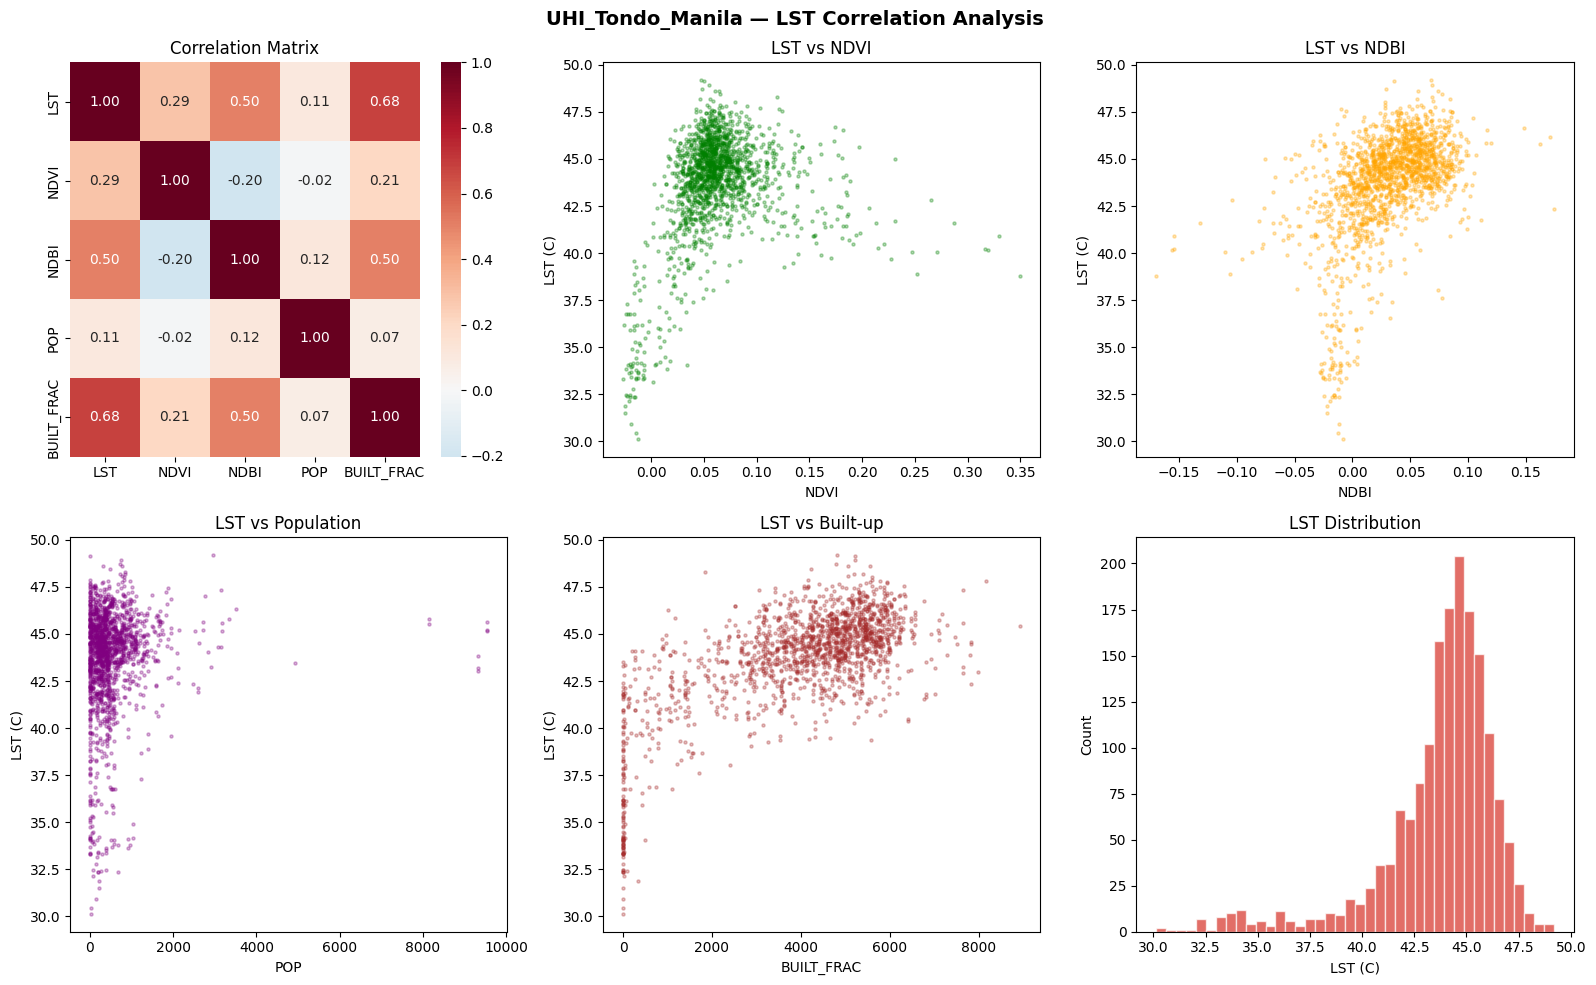

In [28]:
# ============================================================
# 9C. CORRELATION ANALYSIS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'{PROJECT_NAME} — LST Correlation Analysis', fontsize=14, fontweight='bold')

corr = df[['LST','NDVI','NDBI','POP','BUILT_FRAC']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=axes[0,0], fmt='.2f')
axes[0,0].set_title('Correlation Matrix')

for ax, col, c, t in [(axes[0,1],'NDVI','green','LST vs NDVI'),
                       (axes[0,2],'NDBI','orange','LST vs NDBI'),
                       (axes[1,0],'POP','purple','LST vs Population'),
                       (axes[1,1],'BUILT_FRAC','brown','LST vs Built-up')]:
    ax.scatter(df[col], df['LST'], alpha=0.3, s=5, c=c)
    ax.set_xlabel(col); ax.set_ylabel('LST (C)'); ax.set_title(t)

axes[1,2].hist(df['LST'], bins=40, color='#d73027', alpha=0.7, edgecolor='white')
axes[1,2].set_xlabel('LST (C)'); axes[1,2].set_ylabel('Count'); axes[1,2].set_title('LST Distribution')

plt.tight_layout()
plt.savefig('lst_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Temporal LST Trends

 Year  Mean_LST  Mean_NDVI  Scenes
 2022 45.895902   0.057431       6
 2023 41.262224   0.052673       8
 2024 44.282035   0.053212      10
 2025 40.553266   0.058578       3


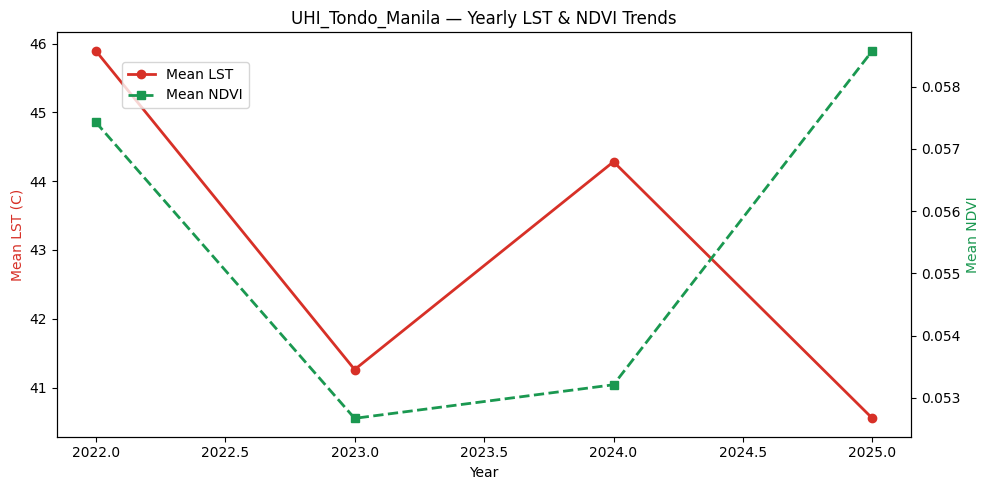

In [29]:
# ============================================================
# 10. YEARLY MEAN LST TREND
# ============================================================
yearly_stats = []
for yr in range(YEAR_START, YEAR_END + 1):
    yr_col = l9_col.filter(ee.Filter.calendarRange(yr, yr, 'year'))
    n = yr_col.size().getInfo()
    if n == 0:
        continue
    yr_mean = yr_col.select('LST').mean().reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi,
        scale=30, maxPixels=1e9).get('LST').getInfo()
    yr_ndvi = yr_col.select('NDVI').mean().reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi,
        scale=30, maxPixels=1e9).get('NDVI').getInfo()
    yearly_stats.append({'Year': yr, 'Mean_LST': yr_mean, 'Mean_NDVI': yr_ndvi, 'Scenes': n})

yr_df = pd.DataFrame(yearly_stats)
print(yr_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(yr_df['Year'], yr_df['Mean_LST'], 'o-', color='#d73027', lw=2, label='Mean LST')
ax1.set_xlabel('Year'); ax1.set_ylabel('Mean LST (C)', color='#d73027')
ax2 = ax1.twinx()
ax2.plot(yr_df['Year'], yr_df['Mean_NDVI'], 's--', color='#1a9850', lw=2, label='Mean NDVI')
ax2.set_ylabel('Mean NDVI', color='#1a9850')
plt.title(f'{PROJECT_NAME} — Yearly LST & NDVI Trends')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig('lst_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Heat-Exposure Vulnerability Index
Each layer is min-max normalized to [0, 1], then weighted and summed.

In [30]:
# ============================================================
# 11. COMPOSITE VULNERABILITY INDEX
# ============================================================
def min_max_normalize(image, geometry, band_name=None, scale=30):
    if band_name:
        image = image.select(band_name)
    mm = image.reduceRegion(reducer=ee.Reducer.minMax(),
                            geometry=geometry, scale=scale, maxPixels=1e9)
    keys = mm.keys().getInfo()
    min_key = [k for k in keys if '_min' in k][0]
    max_key = [k for k in keys if '_max' in k][0]
    return image.subtract(ee.Number(mm.get(min_key))).divide(
        ee.Number(mm.get(max_key)).subtract(ee.Number(mm.get(min_key)))).clamp(0, 1)

lst_norm   = min_max_normalize(annual_composite, aoi, 'LST').rename('LST_norm')
pop_norm   = min_max_normalize(pop, aoi).rename('POP_norm')
built_norm = min_max_normalize(ghsl, aoi).rename('BUILT_norm')
ndvi_norm  = min_max_normalize(annual_composite, aoi, 'NDVI')
ndvi_inv   = ee.Image.constant(1).subtract(ndvi_norm).rename('NDVI_inv_norm')
health_norm = min_max_normalize(health_dist, aoi).rename('HEALTH_norm')

vulnerability = (lst_norm.multiply(W_LST)
                 .add(pop_norm.multiply(W_POP))
                 .add(built_norm.multiply(W_BUILD))
                 .add(ndvi_inv.multiply(W_NDVI))
                 .add(health_norm.multiply(W_HEALTH))
                ).rename('vulnerability').clip(aoi)

print(f"Vulnerability index computed. Weights: LST={W_LST}, POP={W_POP}, BUILD={W_BUILD}, NDVI={W_NDVI}, HEALTH={W_HEALTH}")


Vulnerability index computed. Weights: LST=0.3, POP=0.25, BUILD=0.2, NDVI=0.15, HEALTH=0.1


In [31]:
# ============================================================
# 12. MAP — VULNERABILITY INDEX
# ============================================================
vuln_vis = {'min': 0, 'max': 1, 'palette': [
    '1a9850','91cf60','d9ef8b','ffffbf','fee08b','fc8d59','d73027']}

m3 = make_map(center_lat, center_lon, zoom=14)
add_ee_layer(m3, vulnerability, vuln_vis, 'Heat Vulnerability Index')
add_ee_layer(m3, lst_norm.clip(aoi),   {'min':0,'max':1,'palette':['blue','yellow','red']}, 'LST (norm)', shown=False)
add_ee_layer(m3, pop_norm.clip(aoi),   {'min':0,'max':1,'palette':['white','purple']}, 'Population (norm)', shown=False)
add_ee_layer(m3, ndvi_inv.clip(aoi),   {'min':0,'max':1,'palette':['green','white','brown']}, 'Vegetation Deficit', shown=False)
add_ee_layer(m3, built_norm.clip(aoi), {'min':0,'max':1,'palette':['white','grey','black']}, 'Built-up (norm)', shown=False)
folium.LayerControl().add_to(m3)
m3


## 12. Barangay-Level Vulnerability Ranking

In [32]:
# ============================================================
# 13. BARANGAY-LEVEL RANKING
# ============================================================
try:
    barangays = (ee.FeatureCollection("projects/sat-io/open-datasets/geoboundaries/CGAZ_ADM4")
                 .filterBounds(aoi))
    brgy_count = barangays.size().getInfo()
    if brgy_count == 0:
        raise Exception("No features found")

    brgy_vuln = vulnerability.reduceRegions(
        collection=barangays,
        reducer=ee.Reducer.mean().setOutputs(['vuln_mean']), scale=30)
    brgy_lst = annual_composite.select('LST').reduceRegions(
        collection=barangays,
        reducer=ee.Reducer.mean().setOutputs(['lst_mean']), scale=30)

    vuln_list = brgy_vuln.getInfo()['features']
    lst_list  = brgy_lst.getInfo()['features']
    ranking = []
    for v, l in zip(vuln_list, lst_list):
        name = v['properties'].get('shapeName', v['properties'].get('NAME_4', 'Unknown'))
        ranking.append({
            'Barangay': name,
            'Vulnerability': round(v['properties'].get('vuln_mean', 0), 3),
            'Mean LST (C)': round(l['properties'].get('lst_mean', 0), 2)})
    rank_df = pd.DataFrame(ranking).sort_values('Vulnerability', ascending=False)
    print("Barangay Vulnerability Ranking")
    print("=" * 50)
    print(rank_df.to_string(index=False))
except Exception as e:
    print(f"Barangay boundaries not available: {e}")
    print("  Upload a boundary shapefile as a GEE asset and update the path above.")


Barangay boundaries not available: Collection.loadTable: Collection asset 'projects/sat-io/open-datasets/geoboundaries/CGAZ_ADM4' not found.
  Upload a boundary shapefile as a GEE asset and update the path above.


---
## 13. Export Results to Google Drive

In [33]:
# ============================================================
# 14. EXPORT TO GOOGLE DRIVE
# ============================================================
export_params = dict(region=aoi, scale=30, maxPixels=1e9, crs='EPSG:4326')

for img, name in [(vulnerability.toFloat(), 'vulnerability_index'),
                   (annual_composite.select('LST').toFloat(), 'annual_LST'),
                   (uhi_dry.toFloat(), 'UHI_dry')]:
    task = ee.batch.Export.image.toDrive(
        image=img, description=f'{PROJECT_NAME}_{name}',
        folder=PROJECT_NAME, **export_params)
    task.start()
    print(f"Export started: {PROJECT_NAME}_{name}")

print(f"\nCheck progress: https://code.earthengine.google.com/tasks")

stats_df.to_csv('lst_summary_statistics.csv', index=False)
if 'yr_df' in dir():
    yr_df.to_csv('lst_yearly_trends.csv', index=False)
if 'rank_df' in dir():
    rank_df.to_csv('barangay_vulnerability_ranking.csv', index=False)
print("CSV files saved.")


Export started: UHI_Tondo_Manila_vulnerability_index
Export started: UHI_Tondo_Manila_annual_LST
Export started: UHI_Tondo_Manila_UHI_dry

Check progress: https://code.earthengine.google.com/tasks
CSV files saved.


---
## 14. [Phase 3] Cooling Site Identification *(lower priority)*

In [34]:
# ============================================================
# 15. COOLING SITE IDENTIFICATION
# ============================================================
cool_classes = esa_lc.eq(10).Or(esa_lc.eq(20)).Or(esa_lc.eq(30))
cool_mask = cool_classes.selfMask().rename('cool_areas')

vuln_p75 = vulnerability.reduceRegion(
    reducer=ee.Reducer.percentile([75]),
    geometry=aoi, scale=30, maxPixels=1e9).get('vulnerability')
high_vuln = vulnerability.gte(ee.Number(vuln_p75)).selfMask()

m4 = make_map(center_lat, center_lon, zoom=14)
add_ee_layer(m4, vulnerability, vuln_vis, 'Vulnerability Index')
add_ee_layer(m4, high_vuln.clip(aoi), {'min':0,'max':1,'palette':['red']}, 'High Vulnerability Zones')
add_ee_layer(m4, cool_mask.clip(aoi), {'min':0,'max':1,'palette':['00ff00']}, 'Potential Cool Spaces', shown=False)
folium.LayerControl().add_to(m4)
m4


---
## Summary & Next Steps

### Outputs:
1. Seasonal LST composites (dry / wet / annual) at 30 m
2. UHI intensity anomaly maps
3. Statistical analysis — zonal stats, correlations, temporal trends
4. Heat-exposure vulnerability index + barangay ranking
5. Cooling site candidates
6. Exported GeoTIFFs to Google Drive

### To use for a different study area:
1. Change `AOI_BBOX` in the Configuration cell
2. Adjust dates / seasons if needed
3. Re-run all cells

---
*MSF Geo-Humanitarian Project · University of Salzburg Z_GIS*
